# X (formerly Twitter) Sentiment Analysis of U.S. Airlines 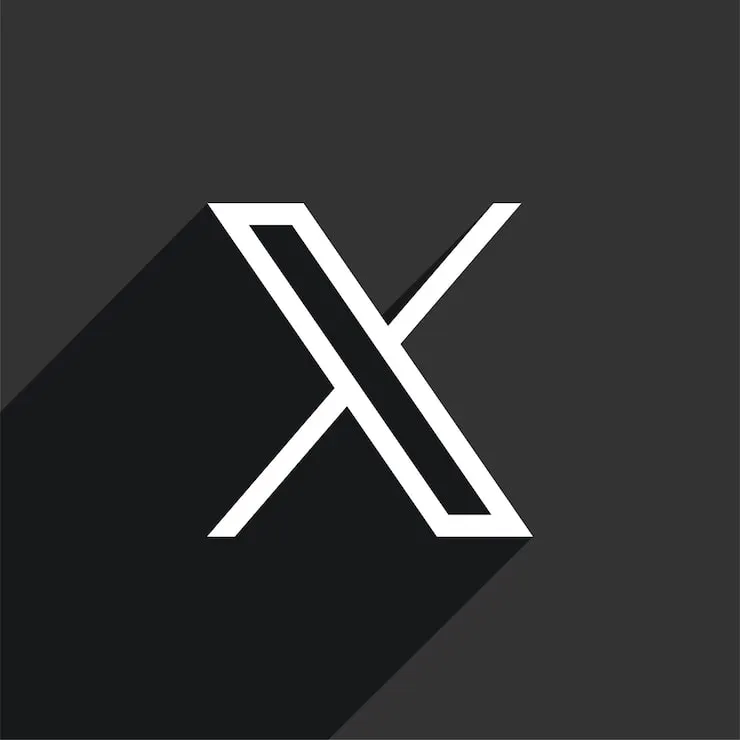
### Advanced NLP Pipeline — Classical ML + BERT Transformer

---

## 📋 Project Overview

This project builds an **end-to-end sentiment analysis system** capable 
of classifying airline customer tweets into three sentiment categories:
**Positive**, **Negative**, and **Neutral**.

It demonstrates two complete NLP approaches side by side — traditional 
Machine Learning with TF-IDF vectorization, and a state-of-the-art 
**BERT Transformer** fine-tuned on domain-specific data — allowing a 
direct, honest comparison between classical and deep learning methods.

---

## 🎯 Business Context

Airlines receive thousands of customer tweets daily. Manual review is 
impossible at scale. An automated sentiment classifier enables:

- **Real-time customer feedback monitoring**
- **Early detection of service failures** before they escalate
- **Routing negative tweets** to support teams automatically
- **Tracking sentiment trends** over time by airline, route, or issue type

---

## 📦 Dataset

| Property | Detail |
|---|---|
| **Source** | Twitter US Airline Sentiment — Kaggle |
| **Size** | ~14,000 tweets |
| **Period** | February 2015 |
| **Airlines** | United, Delta, American, Southwest, US Airways, Virgin America |
| **Target** | `airline_sentiment` → positive / negative / neutral |
| **Challenge** | Real messy text — slang, typos, @mentions, hashtags, URLs |

---

## ⚠️ Key Challenge — Class Imbalance

The dataset is heavily skewed toward negative sentiment — reflecting 
real-world behavior where unhappy customers tweet far more than 
satisfied ones. This imbalance must be handled carefully to avoid 
a model that simply predicts "negative" for everything.

---

## 🗺️ Pipeline

| Step | Description | Tools |
|---|---|---|
| 1 | Load & explore data | kagglehub, pandas |
| 2 | EDA — distributions, word clouds | matplotlib, wordcloud |
| 3 | Text cleaning & lemmatization | nltk, regex |
| 4 | Train/test split | sklearn |
| 5 | TF-IDF vectorization | TfidfVectorizer |
| 6 | Classical model comparison | LR, SVM, RF, XGBoost, NaiveBayes |
| 7 | Handle class imbalance | class_weight, SMOTE |
| 8 | Tune the winner | BayesSearchCV |
| 9 | Feature importance | Most influential words per sentiment |
| 10 | Error analysis | What does the model get wrong and why? |
| 11 | BERT fine-tuning | HuggingFace Transformers, PyTorch |
| 12 | Classical vs BERT comparison | Final scorecard |
| 13 | SHAP values | Model interpretability |
| 14 | End-to-end inference | Predict on raw new text |
| 15 | Export | joblib + HuggingFace save |
| 16 | Conclusion | Honest limitations & next steps |

---

## 🧰 Two Approaches Compared

### Approach 1 — Classical ML (TF-IDF + Sklearn)
Fast, interpretable, explainable. Treats text as a bag of words — 
word meaning and context are lost, but performance is surprisingly strong.

### Approach 2 — BERT Transformer (Deep Learning)
Slow to train but understands word meaning in context. "not good" and 
"good" are treated completely differently — a capability classical 
models fundamentally lack.

---

## 📐 Coding Standards

- All text cleaning applied **before** the split where safe
- Vectorization and modeling inside **pipelines** — no leakage
- Same `StratifiedKFold` CV strategy across **all** models
- Test

## 📊 Data Source

We load the Twitter US Airline Sentiment dataset directly from Kaggle 
using `kagglehub`. The dataset contains ~14,000 real customer tweets 
from February 2015 across 6 major US airlines.

> Source: [Twitter US Airline Sentiment dataset](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment)

#### 📥 Loading the Dataset

We read the located CSV into a pandas DataFrame — this is our raw, 
unprocessed dataset, straight from the Kaggle download.

In [125]:
%pip install pandas numpy matplotlib seaborn scikit-learn nltk jupyterlab transformers torch datasets wordcloud shap watermark imbalanced-learn xgboost kagglehub -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [126]:
# ============================================================
# 📦 DEPENDENCIES
# ============================================================

# ✅ Core
import os
import re
import warnings
import logging
import joblib
import numpy as np
import pandas as pd
import matplotlib as plt

warnings.filterwarnings('ignore', category=UserWarning)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ✅ Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from wordcloud import WordCloud
plt.style.use('dark_background')

# ✅ Text Processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# ✅ Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# ✅ Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

# ✅ Pipeline
from sklearn.pipeline import Pipeline

# ✅ Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score
)

# ✅ Validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_val_predict
)

print("✅ All dependencies loaded!")

✅ All dependencies loaded!


In [127]:
# Load the watermark extension to log the environment state
%reload_ext watermark

# Display professional metadata tracking our data engineering stack (NO SPACES after commas)
%watermark -a "Maykon - Twitter US Airline Sentiment Analysis 🐦 (Didn't find a blue bird!) " -d -u -v -p pandas,numpy,matplotlib,seaborn,scikit-learn,nltk,jupyterlab,transformers,torch,datasets,wordcloud,shap,watermark,imbalanced-learn,xgboost,kagglehub

Author: Maykon - Twitter US Airline Sentiment Analysis 🐦 (Didn't find a blue bird!) 

Last updated: 2026-09-10

Python implementation: CPython
Python version       : 3.13.7
IPython version      : 9.17.1

pandas          : 3.0.5
numpy           : 2.5.3
matplotlib      : 3.11.1
seaborn         : 0.13.2
scikit-learn    : 1.9.0
nltk            : 3.10.3
jupyterlab      : 4.6.3
transformers    : 5.16.1
torch           : 2.14.0
datasets        : 5.0.1
wordcloud       : 1.9.6
shap            : 0.52.0
watermark       : 2.6.0
imbalanced-learn: 0.14.2
xgboost         : 3.4.1
kagglehub       : 1.0.2



> OBS: This project was built with assistance from Claude (Anthropic) for 
> code review, debugging, and explanation throughout the notebook.

In [128]:
# --- AUTOMATED KAGGLE INGESTION ---
# Download the latest version of dataset
path = kagglehub.dataset_download("crowdflower/twitter-airline-sentiment")
print("🚀 Path to dataset files:", path)

🚀 Path to dataset files: C:\Users\LarTI\.cache\kagglehub\datasets\crowdflower\twitter-airline-sentiment\versions\4


In [129]:
# --- LOCATING AND READING THE CSV ---
# List out all files inside the downloaded repository path to spot the target file
all_files = os.listdir(path)
print("📂 Files discovered in directory:", all_files)

# Filter out all CSV files dynamically
csv_files = [file for file in all_files if file.endswith('.csv')]

if len(csv_files) == 0:
    raise FileNotFoundError("❌ Critical Error: No CSV files found in the downloaded folder!")
else:
    # Grab the primary CSV file found
    csv_filename = csv_files[0]
    full_csv_path = os.path.join(path, csv_filename)
    print(f"🎯 Target CSV located: {csv_filename}")

📂 Files discovered in directory: ['database.sqlite', 'Tweets.csv']
🎯 Target CSV located: Tweets.csv


In [130]:
# Ingest the dataset into a pandas DataFrame
df = pd.read_csv(full_csv_path)
print(f"✅ Dataset successfully loaded! Named 'df', Shape: {df.shape[0]} rows, {df.shape[1]} columns.")

✅ Dataset successfully loaded! Named 'df', Shape: 14640 rows, 15 columns.


In [131]:
# Display the first 5 records to see our column properties and labels
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [132]:
df.shape # (columns, rows)
print("Number of columns:", df.shape[1])
print("Number of rows:", df.shape[0])

Number of columns: 15
Number of rows: 14640


In [133]:
df.sample(15) # Random 15 rows

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
1340,569812898815614977,negative,1.0000,Cancelled Flight,1.0000,United,NaN,sarahali,NaN,0,@united this is the second time my flights bee...,NaN,2015-02-23 02:55:56 -0800,NaN,NaN
6661,567739785406873601,positive,1.0000,NaN,NaN,Southwest,NaN,Bkloomer,NaN,0,@SouthwestAir Karen with customer service was ...,NaN,2015-02-17 09:38:07 -0800,NaN,Central Time (US & Canada)
8160,568649053711380480,neutral,0.6701,NaN,NaN,Delta,NaN,mhoffma8,NaN,0,@JetBlue - I look forward to getting this reso...,NaN,2015-02-19 21:51:14 -0800,NaN,NaN
12469,570176104541122561,negative,1.0000,Flight Attendant Complaints,1.0000,American,NaN,SouthSeth,NaN,0,@AmericanAir merged airlines do not work for F...,NaN,2015-02-24 02:59:11 -0800,Crestwood,Eastern Time (US & Canada)
7035,569948928864600064,neutral,0.6926,NaN,0.0000,Delta,NaN,akaTrig,NaN,0,Too Late Flight. RT “@JetBlue: Our fleet's on ...,NaN,2015-02-23 11:56:28 -0800,Bawston,Eastern Time (US & Canada)
13737,569730304111325184,negative,0.6629,Late Flight,0.6629,American,NaN,jjkend,NaN,0,@AmericanAir can I get home before 12 or no?,NaN,2015-02-22 21:27:44 -0800,NaN,Mountain Time (US & Canada)
10763,568898634923843586,negative,0.6522,Customer Service Issue,0.3478,US Airways,NaN,chrisseifert83,NaN,0,@USAirways nothing important to do. Why was I...,NaN,2015-02-20 14:22:58 -0800,"Stamford, Ct",Eastern Time (US & Canada)
10007,569578016843669504,negative,1.0000,Late Flight,1.0000,US Airways,NaN,DAngel082,NaN,0,@USAirways going to miss my connection because...,NaN,2015-02-22 11:22:36 -0800,New York,NaN
1391,569745645956771840,negative,1.0000,Cancelled Flight,1.0000,United,NaN,patlee,NaN,0,"@united Actually, the flight was just Cancelle...","[0.0, 0.0]",2015-02-22 22:28:42 -0800,"Bay Area, CA",Pacific Time (US & Canada)
596,570259691579809792,negative,0.6957,Lost Luggage,0.6957,United,NaN,jakepoznak,NaN,0,@united they helped me at the baggage service ...,NaN,2015-02-24 08:31:20 -0800,NaN,Eastern Time (US & Canada)


In [134]:
df.tail() #Displays the last 5 rows of the DataFrame df.

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
14635,569587686496825344,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,569587371693355008,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN
14637,569587242672398336,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN
14638,569587188687634433,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada)
14639,569587140490866689,neutral,0.6771,NaN,0.0000,American,NaN,daviddtwu,NaN,0,@AmericanAir we have 8 ppl so we need 2 know h...,NaN,2015-02-22 11:58:51 -0800,"dallas, TX",NaN


In [135]:
df.dtypes #Displays the data type of each column in the DataFrame.

tweet_id                          int64
airline_sentiment                   str
airline_sentiment_confidence    float64
negativereason                      str
negativereason_confidence       float64
airline                             str
airline_sentiment_gold              str
name                                str
negativereason_gold                 str
retweet_count                     int64
text                                str
tweet_coord                         str
tweet_created                       str
tweet_location                      str
user_timezone                       str
dtype: object

In [136]:
df.columns #Returns a list (Index object) containing the names of all columns in the DataFrame.

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='str')

### 📊 Exploratory Data Analysis (EDA)

Before any modeling, we explore the dataset to understand:
- How many tweets per sentiment class — and how imbalanced they are
- Which airlines generate the most tweets
- What words dominate each sentiment category
- The average tweet length per sentiment

This shapes every decision we make in the pipeline — especially 
how we handle class imbalance.

In [137]:
# ============================================================
# 📋 BASIC INFO
# ============================================================

print("=" * 50)
print("📋 DATASET OVERVIEW")
print("=" * 50)
print(f"Total tweets     : {df.shape[0]:,}")
print(f"Total columns    : {df.shape[1]}")
print(f"Missing values   : {df.isnull().sum().sum()}")
print()
print("📊 Sentiment Distribution:")
print(df['airline_sentiment'].value_counts())
print()
print("📊 Sentiment % Distribution:")
print((df['airline_sentiment'].value_counts(normalize=True) * 100).round(1))

📋 DATASET OVERVIEW
Total tweets     : 14,640
Total columns    : 15
Missing values   : 61962

📊 Sentiment Distribution:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

📊 Sentiment % Distribution:
airline_sentiment
negative    62.7
neutral     21.2
positive    16.1
Name: proportion, dtype: float64


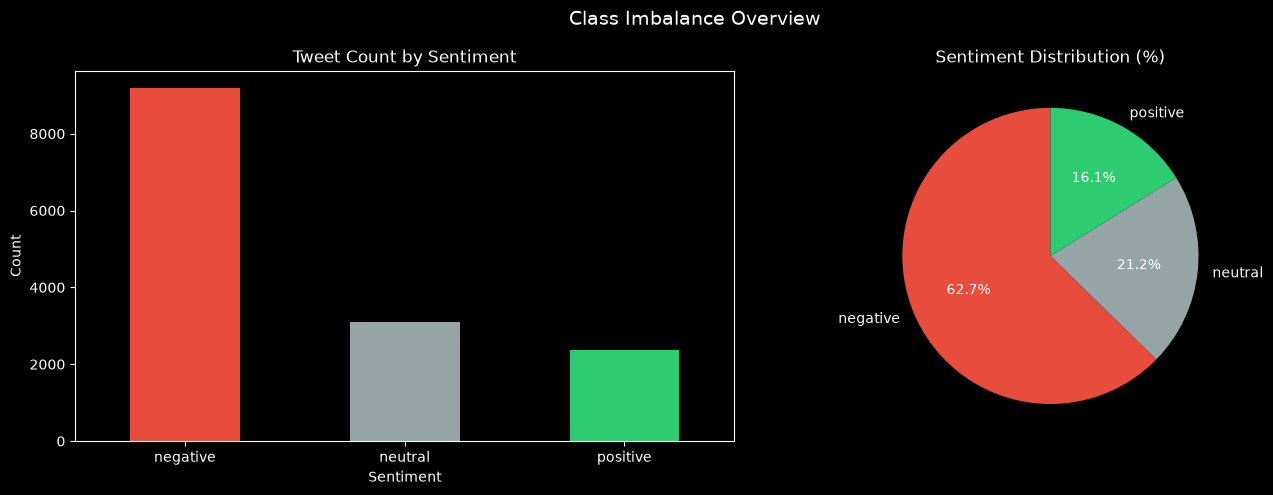

In [138]:
# ============================================================
# 📊 SENTIMENT DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
colors = ['#E74C3C', '#95A5A6', '#2ECC71']
df['airline_sentiment'].value_counts().plot(
    kind  = 'bar',
    ax    = axes[0],
    color = colors,
    edgecolor = 'none'
)
axes[0].set_title('Tweet Count by Sentiment')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['airline_sentiment'].value_counts().plot(
    kind    = 'pie',
    ax      = axes[1],
    colors  = colors,
    autopct = '%1.1f%%',
    startangle = 90
)
axes[1].set_title('Sentiment Distribution (%)')
axes[1].set_ylabel('')

plt.suptitle('Class Imbalance Overview', fontsize=14)
plt.tight_layout()
plt.show()

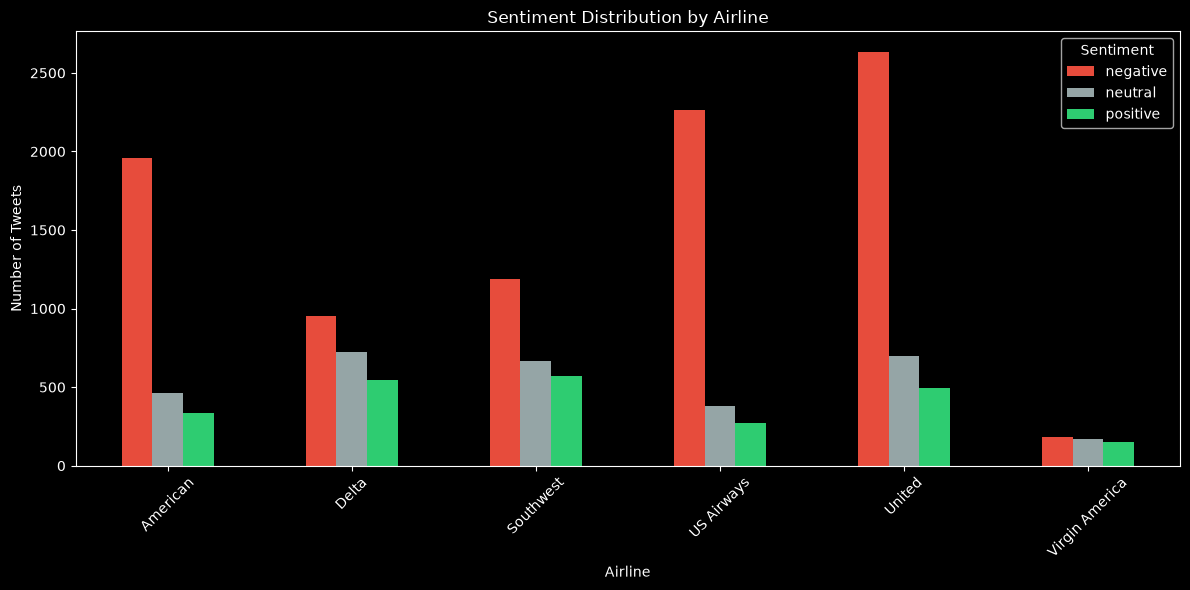

In [139]:
# ============================================================
# ✈️ TWEETS PER AIRLINE
# ============================================================

airline_sentiment = df.groupby(['airline', 'airline_sentiment']).size().unstack()

airline_sentiment.plot(
    kind    = 'bar',
    figsize = (12, 6),
    color   = colors,
    edgecolor = 'none'
)
plt.title('Sentiment Distribution by Airline')
plt.xlabel('Airline')
plt.ylabel('Number of Tweets')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

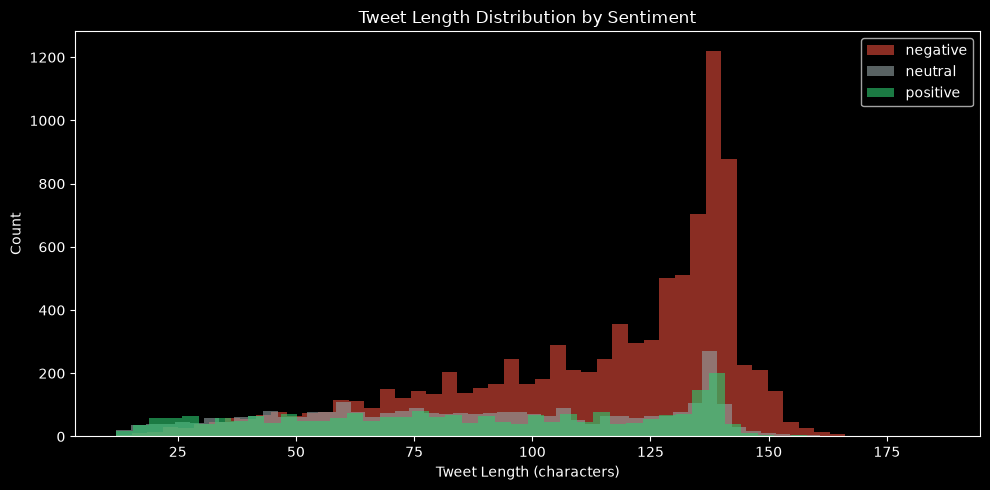

                    count   mean   std   min   25%    50%    75%    max
airline_sentiment                                                      
negative           9178.0  113.9  30.7  12.0  96.0  126.0  138.0  176.0
neutral            3099.0   87.4  37.7  12.0  57.0   87.0  123.0  167.0
positive           2363.0   86.1  39.5  12.0  52.0   86.0  124.0  186.0


In [140]:
# ============================================================
# 📏 TWEET LENGTH ANALYSIS
# ============================================================

df['tweet_length'] = df['text'].apply(len)

plt.figure(figsize=(10, 5))
for sentiment, color in zip(['negative', 'neutral', 'positive'], colors):
    subset = df[df['airline_sentiment'] == sentiment]['tweet_length']
    plt.hist(subset, bins=50, alpha=0.6, label=sentiment, color=color)

plt.title('Tweet Length Distribution by Sentiment')
plt.xlabel('Tweet Length (characters)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print(df.groupby('airline_sentiment')['tweet_length'].describe().round(1))

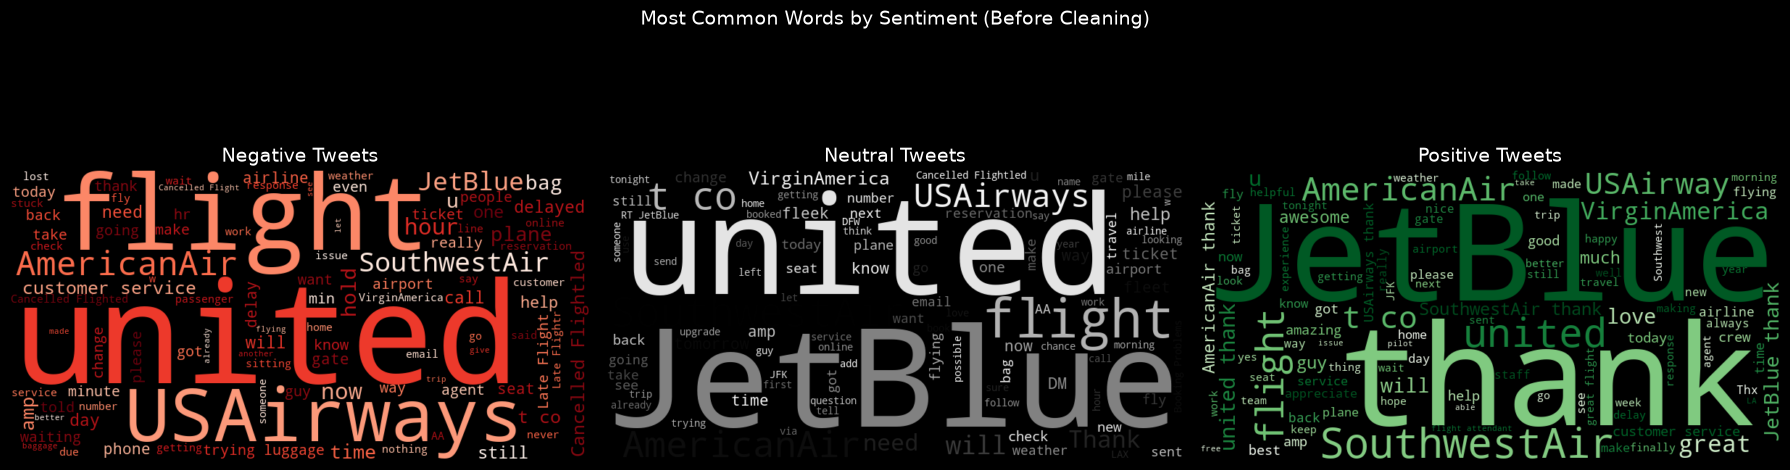

In [141]:
# ============================================================
# ☁️ WORD CLOUDS PER SENTIMENT
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sentiments = {
    'negative' : ('#E74C3C', axes[0]),
    'neutral'  : ('#95A5A6', axes[1]),
    'positive' : ('#2ECC71', axes[2])
}

for sentiment, (color, ax) in sentiments.items():
    text = ' '.join(df[df['airline_sentiment'] == sentiment]['text'].tolist())
    wc   = WordCloud(
        width            = 800,
        height           = 400,
        background_color = 'black',
        colormap         = 'Reds' if sentiment == 'negative' else
                           'Greens' if sentiment == 'positive' else 'Greys',
        max_words        = 100
    ).generate(text)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.capitalize()} Tweets', fontsize=14)
    ax.axis('off')

plt.suptitle('Most Common Words by Sentiment (Before Cleaning)', fontsize=14)
plt.tight_layout()
plt.show()

**Key findings from EDA:**
- The dataset is heavily skewed toward **negative sentiment** — 
  this must be handled during modeling
- Some airlines generate far more complaints than others
- Word clouds show raw unclean text — @mentions, URLs, and 
  stopwords dominate before cleaning
- These patterns directly motivate our text cleaning pipeline

### 🧹 Data Preprocessing & Hygiene

In [142]:
df.isna().sum() # Count missing values per column

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
tweet_length                        0
dtype: int64

In [143]:
df.drop(columns=['tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone', 'tweet_id', 'airline_sentiment_gold', 'negativereason_gold'], inplace=True)
print(f'The number of columns after dropping unnecessary columns is: {df.shape[1]}')

The number of columns after dropping unnecessary columns is: 9


In [144]:
print(f'The number of duplicate rows is: {df.duplicated().sum()}') # Count duplicate rows

The number of duplicate rows is: 41


In [145]:
df.drop_duplicates(inplace=True) # Remove duplicate rows from the DataFrame df.
print("Number of duplicate rows Now:", df.duplicated().sum()) # After dropping duplicates, check again to confirm that there are no duplicate rows remaining in the DataFrame df.

Number of duplicate rows Now: 0


In [146]:
# ============================================================
# 🧹 COLUMN NAME SANITIZATION
# ============================================================
df.columns = (
    df.columns
    .str.lower()                                        # lowercase everything
    .str.strip()                                        # remove leading/trailing whitespace
    .str.replace(r"[^a-z0-9]+", "_", regex=True)       # replace anything not a letter/number with _
    .str.strip("_")                                     # remove leading/trailing underscores
)

print("✅ Columns sanitized:")
print(df.columns.tolist())

✅ Columns sanitized:
['airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'name', 'retweet_count', 'text', 'tweet_length']


In [147]:
# Drop useless sparse gold standard columns
dfc = df.copy()  # Create a copy of the DataFrame df to dfc for further processing

# Fill missing values in metadata if you plan to use them
dfc['negativereason'] = dfc['negativereason'].fillna('N/A')
dfc['negativereason_confidence'] = dfc['negativereason_confidence'].fillna(0.0)

# Check again to ensure no NaNs remain
print(dfc.isna().sum())

airline_sentiment               0
airline_sentiment_confidence    0
negativereason                  0
negativereason_confidence       0
airline                         0
name                            0
retweet_count                   0
text                            0
tweet_length                    0
dtype: int64
